# 15.777 Homework 1 (Spring 2024): Convolutional Neural Networks


In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import metrics
import seaborn as sns

# initialize the seeds of different random number generators so that the
# results will be the same every time the notebook is run
keras.utils.set_random_seed(42)

<font color='red'> **Please be sure to make a copy of this notebook in your own Google Drive so that your work is saved!** </font>

# Introduction

Your goal in this exercise is to detect emotion from a facial image. To that end, we will use the 2013 Facial Expression Recognition (FER) dataset.

The dataset consists of ~36,000 images, each annotated with one of seven labels:
* angry
* disgust
* fear
* happy
* sad
* surprise
* neutral

The goal of this homework assignment is to walk you through how to:

1. Build a Convolutional Neural Network (CNN) *from scratch* to detect emotion in facial images (Problems 1 and 2)
2. Use data augmentation to increase the size of your training data (Problem 3)
3. Use transfer learning to customize a pretrained model to solve the same problem (Problem 4)

But first, let's get the data.

In [2]:
!wget -q -O fer2013.csv -P ./ https://dl.dropbox.com/scl/fi/e2ik6aryemboameq1rwwn/fer2013.csv?rlkey=ux7tyge6flk9nnuul9desizgf&dl=0

The data has 35887 rows and 3 columns:
* Emotion - encoded as the numbers 0 (anger) through 6 (neutral)
* Pixels - A space-separated list of numbers representing the pixels of this image.
* Usage - No need to worry about this column

In [3]:
data = pd.read_csv('fer2013.csv')
data

,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training
...,...,...,...
35882,6,50 36 17 22 23 29 33 39 34 37 37 37 39 43 48 5...,PrivateTest
35883,3,178 174 172 173 181 188 191 194 196 199 200 20...,PrivateTest
35884,0,17 17 16 23 28 22 19 17 25 26 20 24 31 19 27 9...,PrivateTest
35885,3,30 28 28 29 31 30 42 68 79 81 77 67 67 71 63 6...,PrivateTest


The pixel values for each image is provided as a space-separated list of numbers. How many pixels in an image?

In [4]:
len(data.loc[0, 'pixels'].split(' '))

2304

### Pre-Processing the Pixels (Independent Variable)

Each image is encoded as a list of 2304 pixels. We will reshape this into an 48x48 image next.

Recall that a color image is represented as a tensor of dimension N by M by 3, where the 3 represents the 3 color channels (red, green and blue). Our images from the FER 2013 dataset are grayscale images, with only a single channel representing the amount of black in the image. This is inconvenient to work with because many pre-trained models used in transfer learning, such as the one we will use in Problem 4, require the input image to have 3 channels.

To get around this, we will take each image, a 48 x 48 tensor and transform it into a 48 x 48 x 3 tensor by simply duplicating it three times. We can think of a greyscale image is one where the red, green and blue color channels are exactly the same.

The following code transforms our dataset into a tensor of shape (35887, 48, 48, 3): a list of 35887 images, each of which are a (48, 48, 3)-shape tensor.

In [5]:
pixels = data['pixels'].tolist()
width, height = 48, 48
faces = []
for pixel_sequence in pixels:
    face = [int(pixel) for pixel in pixel_sequence.split(' ')] # read each face as a 1-d array
    face = np.asarray(face).reshape(width, height) # reshape the length 2304 1-d array into an 48x48 array
    face = np.stack((face,)*3, axis=-1)
    faces.append(face.astype('float32'))

faces = np.asarray(faces)
faces.shape

(35887, 48, 48, 3)

For the first image, i.e. `faces[0]`, we can examine its first channel (corresponding to "red").

In [6]:
faces[0, :, :, 0]

array([[ 70.,  80.,  82., ...,  52.,  43.,  41.],
       [ 65.,  61.,  58., ...,  56.,  52.,  44.],
       [ 50.,  43.,  54., ...,  49.,  56.,  47.],
       ...,
       [ 91.,  65.,  42., ...,  72.,  56.,  43.],
       [ 77.,  82.,  79., ..., 105.,  70.,  46.],
       [ 77.,  72.,  84., ..., 106., 109.,  82.]], dtype=float32)

This is the exact same as the second channel (corresponding to "blue"). And similarly for green.

In [7]:
faces[0, :, :, 1]

array([[ 70.,  80.,  82., ...,  52.,  43.,  41.],
       [ 65.,  61.,  58., ...,  56.,  52.,  44.],
       [ 50.,  43.,  54., ...,  49.,  56.,  47.],
       ...,
       [ 91.,  65.,  42., ...,  72.,  56.,  43.],
       [ 77.,  82.,  79., ..., 105.,  70.,  46.],
       [ 77.,  72.,  84., ..., 106., 109.,  82.]], dtype=float32)

### Pre-Processing for Emotions (Dependent Variable)

Next, let's take a look at how emotion (the dependent variable) is encoded. We have that 0 = 'angry', 1 = 'disgust', ... 6 = 'neutral'.

In [8]:
data.emotion.unique()

array([0, 2, 4, 6, 3, 5, 1])

We will convert emotion to a one-hot encoding using the `pd.get_dummies` function.

In [9]:
emotions = pd.get_dummies(data['emotion']).to_numpy() # each emotion is 'one-hot' encoded as a 7-dim vector
emotions_names = ('angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral')
emotions.shape

(35887, 7)

### Example Images
Lets take a look at some of these fun images!

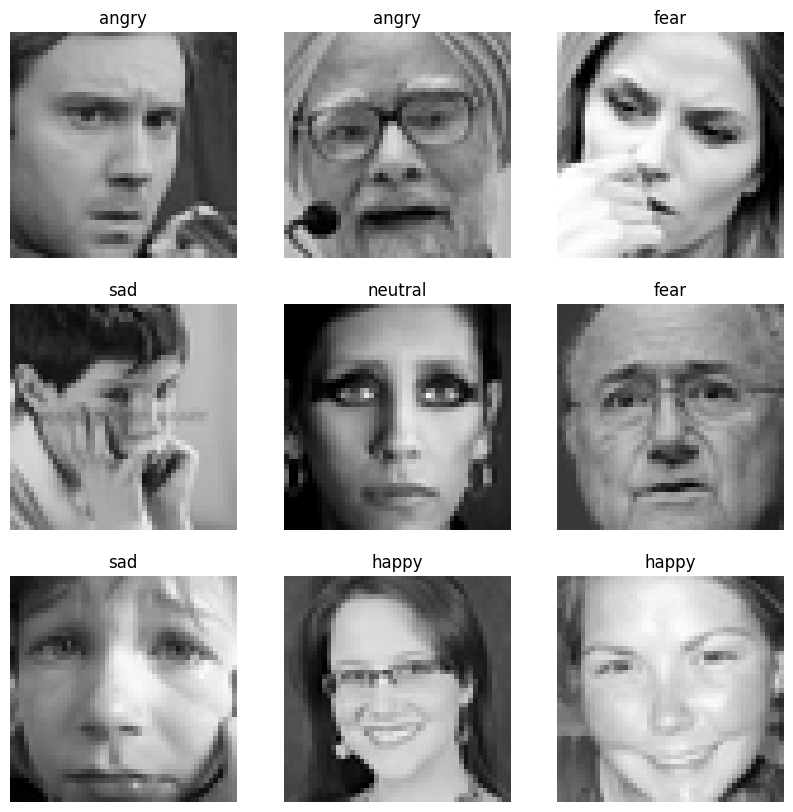

In [10]:
fig = plt.figure(figsize=(10, 10))
for i in range(9):
    ax = fig.add_subplot(3, 3, i+1)
    ax.set_title(f"{emotions_names[np.argmax(emotions[i])]}")
    ax.imshow(faces[i].astype('uint8'))
    ax.axis('off')

### Train/Test Split
As in the original dataset, we will reserve the first 28,709 images for training and the rest for testing.

In [11]:
train_faces, train_emotions =  faces[:28709], emotions[:28709]
test_faces, test_emotions =  faces[28709:], emotions[28709:]

train_faces.shape, train_emotions.shape, test_faces.shape, test_emotions.shape

((28709, 48, 48, 3), (28709, 7), (7178, 48, 48, 3), (7178, 7))

# Problem 1: Base Model [30 Points]
In this problem, we will build a simple CNN with three convolutional blocks, one dense layer and one output layer.



## Part (a): Building the Model [10 points]
We would like to build a CNN with the following model summary. Fill in the code in the cell below so that the output of `model.summary()` matches that of the image above. Be sure to use relu activation for each of the Conv2D layers and the appropriate activation function for the output layer.


![](https://dl.dropbox.com/scl/fi/lrmaupoa243xrrsfj3qiy/cnn_model.PNG?rlkey=n5axqin6vx652qrgduyosg0pc&dl=0)

In [12]:
from os import name
input = keras.Input(shape=(48, 48, 3), name="input")

###### YOUR CODE HERE #####
h = keras.layers.Rescaling(1./255)(input)
h = keras.layers.Conv2D(kernel_size=2, filters=16, activation='relu', name="Conv_1")(h)
h = keras.layers.MaxPooling2D(pool_size=2)(h)

h = keras.layers.Conv2D(kernel_size=2, filters=16, activation='relu', name="Conv_2")(h)
h = keras.layers.MaxPooling2D(pool_size=2)(h)

h = keras.layers.Conv2D(kernel_size=2, filters=16, activation='relu', name="Conv_3")(h)
h = keras.layers.MaxPooling2D(pool_size=2)(h)

h = keras.layers.Flatten()(h)
h = keras.layers.Dense(256, activation='relu', name="Dense_1")(h)
output = keras.layers.Dense(7, activation='softmax', name="Output")(h)
###### YOUR CODE HERE #####

model = keras.Model(input, output, name='CNN_model')
model.summary()

Model: "CNN_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 47, 47, 16)     │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 22, 22, 16)     │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 11, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_3 (Conv2D)                 │ (None, 10, 10, 16)     │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_1 (Dense)                 │ (None, 256)            │       102,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,743 (416.96 KB)

 Trainable params: 106,743 (416.96 KB)

 Non-trainable params: 0 (0.00 B)

## Part (b): Number of Parameters [10 points]
The model above has $106,743$ trainable parameters and is computed by $208 + 1040 + 1040 + 102656 + 1799$. Explain how each of these 5 numbers is calculated and show your computations (e.g. 208 = 16 * 3 * 4 + 16).



* Conv1: (2*2*3+1)*16 =       208
* Conv 2: (2*2*16+1)*16 =   1,040
* Conv 3: (2*2*16+1)*16 =   1,040
* Dense_1: (400+1)* 256 = 102,656
* Output: (256+1) * 7.  =   1,799

For a total of 106,743 trainable params.





## Part (c): Training and Evaluation [10 points]

Let us compile our model and fit it on the training data. Since we one-hot-encoded the dependent variable, we use `categorical_crossentropy`, not `sparse_categorical_crossentropy`.

Fill in the parameters of `model.compile` and `model.fit` below.

* Compile the model using the `categorical_crossentropy` loss, `adam` optimizer and report the `accuracy` metric.
* Fit the model on `train_faces`, `train_emotions` using a batch size of 64, for 30 epochs and a validation split of 20%.

In [13]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

model_history = model.fit(train_faces, train_emotions, batch_size=64, epochs=30, validation_split=0.2)

Epoch 1/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.2972 - loss: 1.7371 - val_accuracy: 0.3669 - val_loss: 1.6484
Epoch 2/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3850 - loss: 1.5829 - val_accuracy: 0.4194 - val_loss: 1.5464
Epoch 3/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4204 - loss: 1.5039 - val_accuracy: 0.4347 - val_loss: 1.4835
Epoch 4/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4489 - loss: 1.4379 - val_accuracy: 0.4580 - val_loss: 1.4304
Epoch 5/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4708 - loss: 1.3829 - val_accuracy: 0.4687 - val_loss: 1.3938
Epoch 6/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4917 - loss: 1.3353 - val_accuracy: 0.4808 - val_loss: 1.3685
Epoch 7/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5104 - loss: 1.2901 - val_accuracy: 0.4871 - val_loss: 1.3452
Epoch 8/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5275 - loss: 1.2473 - val_accuracy: 

**Epochs and Batches.**

In your own words, please explain the relationship between an epoch and a batch in stochastic gradient descent.

we break the training set into equal size batches. We adjust the weights (parameters) for each batch.  1 epoch is an iteration through all the batches.





When we ran `model.fit`, we saw that there are 359 batches per epoch. Please explain how this 359 is calculated. _Hint_: There are 28,709 training data points and 20% is set aside for validation.


batch size = 64
batches / epoch = 28,709 * 0.8 / 64 = 369


**Plotting the Training/Validation Accuracy Curve**

Use the `plot_accuracy` function below to plot the training and validation accuracy across the training epochs.

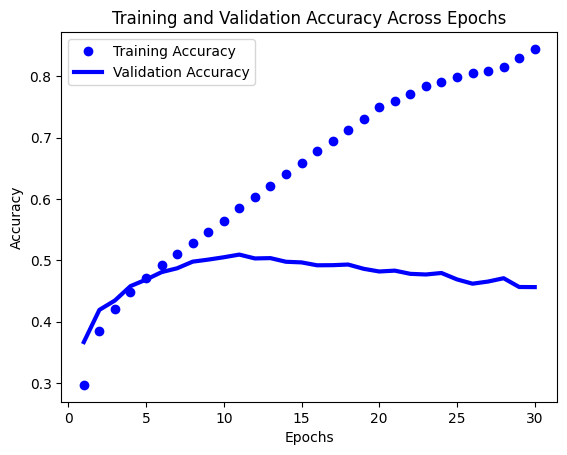

In [14]:
def plot_accuracy(model_history):
    history_dict = model_history.history
    acc = history_dict["accuracy"]
    val_acc = history_dict["val_accuracy"]
    epochs = range(1, len(acc) + 1)
    plt.plot(epochs, acc, "bo", label="Training Accuracy", linewidth=3)
    plt.plot(epochs, val_acc, "b", label="Validation Accuracy", linewidth=3)
    plt.title("Training and Validation Accuracy Across Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

plot_accuracy(model_history)

**Model Accuracy**

Calculate the accuracy on the test set. Write your code below to show the accuracy.

In [15]:
### YOUR CODE HERE ###
model.evaluate(test_faces, test_emotions)

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4581 - loss: 2.3937


[2.393659830093384, 0.45806631445884705]

# Problem 2: Wider and Deeper Models [30 Points]
In this problem, we will modify the model from Problem 1 in two ways:
* Increase the width of the model by adding more filters and more neurons in the dense layer.
* Increase the depth of the model by adding another dense layer.

### Part (a): Wider Model [5 points]
Take the `model` from Problem 1 and modify it into `wider_model` by using 32 filters for the convolution layers instead of 16.


Write your new code below and verify that `wider_model.summary()` looks correct. Your model should have 215,527 parameters.



In [16]:
input = keras.Input(shape=train_faces.shape[1:])

### YOUR CODE BELOW ###
h = keras.layers.Rescaling(1./255)(input)
h = keras.layers.Conv2D(kernel_size=2, filters=32, activation='relu', name="Conv_1")(h)
h = keras.layers.MaxPooling2D(pool_size=2)(h)

h = keras.layers.Conv2D(kernel_size=2, filters=32, activation='relu', name="Conv_2")(h)
h = keras.layers.MaxPooling2D(pool_size=2)(h)

h = keras.layers.Conv2D(kernel_size=2, filters=32, activation='relu', name="Conv_3")(h)
h = keras.layers.MaxPooling2D(pool_size=2)(h)

h = keras.layers.Flatten()(h)
h = keras.layers.Dense(256, activation='relu', name="Dense_1")(h)
output = keras.layers.Dense(7, activation='softmax', name="Output")(h)

### YOUR CODE ABOVE ###

wider_model = keras.Model(input, output, name='wider_cnn')
wider_model.summary()

Model: "wider_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 47, 47, 32)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 22, 22, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_3 (Conv2D)                 │ (None, 10, 10, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_1 (Dense)                 │ (None, 256)            │       205,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 215,527 (841.90 KB)

 Trainable params: 215,527 (841.90 KB)

 Non-trainable params: 0 (0.00 B)

## Part (b): Number of Parameters [5 points]
The model above has $215,527$ trainable parameters and is computed by $416 + 4128 + 4128 + 205056 + 1799$. Explain how each of these 5 numbers is calculated and show your computations.

* Conv1: (2*2*3+1)*32 =       416
* Conv 2: (2*2*32+1)*32 =   4,128
* Conv 3: (2*2*32+1)*32 =   4,128
* Dense_1: (800+1)* 256 = 205,056
* Output: (256+1) * 7. =    1,799

For a total of 215,527 trainable params.





## Part (c): Training and Evaluation [5 points]
Let's train our model and evaluate its performance.

In [17]:
wider_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"] )
wider_model_history = wider_model.fit(train_faces, train_emotions, batch_size=64, epochs=30, validation_split=0.2)

Epoch 1/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.3125 - loss: 1.7061 - val_accuracy: 0.4016 - val_loss: 1.5646
Epoch 2/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4250 - loss: 1.5041 - val_accuracy: 0.4523 - val_loss: 1.4431
Epoch 3/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4695 - loss: 1.3904 - val_accuracy: 0.4885 - val_loss: 1.3625
Epoch 4/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4987 - loss: 1.3139 - val_accuracy: 0.4953 - val_loss: 1.3157
Epoch 5/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5243 - loss: 1.2530 - val_accuracy: 0.5113 - val_loss: 1.2896
Epoch 6/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5489 - loss: 1.1935 - val_accuracy: 0.5228 - val_loss: 1.2719
Epoch 7/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5753 - loss: 1.1331 - val_accuracy: 0.5277 - val_loss: 1.2684
Epoch 8/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6012 - loss: 1.0723 - val_accuracy: 0

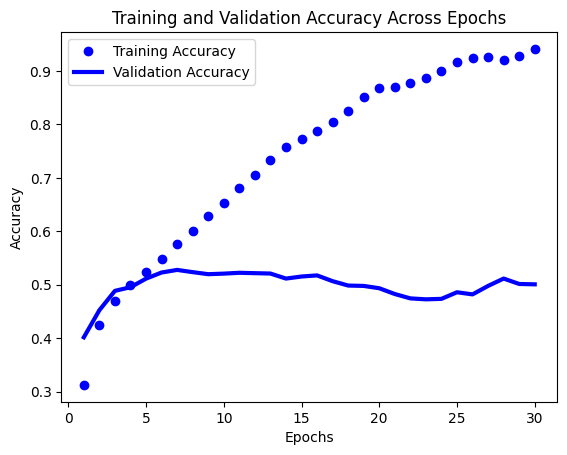

In [18]:
plot_accuracy(wider_model_history)

In [19]:
wider_model.evaluate(test_faces, test_emotions)

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4983 - loss: 3.4684


[3.468407392501831, 0.49832823872566223]

Compare the accuracy curve of `wider_model` to that of `model` from Problem 1. Which shows more evidence of overfitting after 30 epochs? Does that make sense?

<font color='red'> **Your Answer.** </font>

_Please replace this text with your answer_



## Part (d): Deeper Model [5 Points]
Now, build a new model called `deep_model` by taking `model` from Problem 1 and add an additional dense layer of 256 nodes immediately after the original dense layer of 256 nodes. The new model should have a total of 2 dense layers of 256 nodes each and have a total of 172,535 parameters.

Train the model, plot its accuracy vs epochs using the `plot_accuracy` function, and report the model's accuracy on the test set.

In [20]:
input = keras.Input(shape=train_faces.shape[1:])

### YOUR CODE BELOW ###
h = keras.layers.Rescaling(1./255)(input)
h = keras.layers.Conv2D(kernel_size=2, filters=16, activation='relu', name="Conv_1")(h)
h = keras.layers.MaxPooling2D(pool_size=2)(h)

h = keras.layers.Conv2D(kernel_size=2, filters=16, activation='relu', name="Conv_2")(h)
h = keras.layers.MaxPooling2D(pool_size=2)(h)

h = keras.layers.Conv2D(kernel_size=2, filters=16, activation='relu', name="Conv_3")(h)
h = keras.layers.MaxPooling2D(pool_size=2)(h)

h = keras.layers.Flatten()(h)
h = keras.layers.Dense(256, activation='relu', name="Dense_1")(h)
h = keras.layers.Dense(256, activation='relu', name="Dense_2")(h)
output = keras.layers.Dense(7, activation='softmax', name="Output")(h)

### YOUR CODE ABOVE ###

deeper_model = keras.Model(input, output, name='deeper_cnn')
deeper_model.summary()

Model: "deeper_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 47, 47, 16)     │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 23, 23, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 22, 22, 16)     │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 11, 11, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_3 (Conv2D)                 │ (None, 10, 10, 16)     │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_1 (Dense)                 │ (None, 256)            │       102,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 172,535 (673.96 KB)

 Trainable params: 172,535 (673.96 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
deeper_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
deeper_model_history = deeper_model.fit(train_faces, train_emotions, batch_size=64, epochs=30, validation_split=0.2)

Epoch 1/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.2958 - loss: 1.7341 - val_accuracy: 0.3685 - val_loss: 1.6145
Epoch 2/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3905 - loss: 1.5577 - val_accuracy: 0.4122 - val_loss: 1.5103
Epoch 3/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4327 - loss: 1.4613 - val_accuracy: 0.4363 - val_loss: 1.4461
Epoch 4/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4649 - loss: 1.3867 - val_accuracy: 0.4561 - val_loss: 1.4063
Epoch 5/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4911 - loss: 1.3245 - val_accuracy: 0.4648 - val_loss: 1.3910
Epoch 6/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5196 - loss: 1.2678 - val_accuracy: 0.4697 - val_loss: 1.3810
Epoch 7/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5404 - loss: 1.2134 - val_accuracy: 0.4798 - val_loss: 1.3788
Epoch 8/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5647 - loss: 1.1555 - val_accuracy: 0

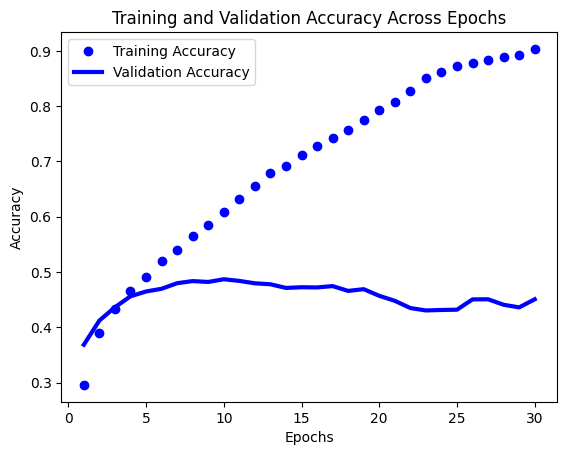

In [22]:
plot_accuracy(deeper_model_history)

In [23]:
# Calculate the test accuracy
### YOUR CODE HERE ###
deeper_model.evaluate(test_faces, test_emotions)

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4525 - loss: 3.6121


[3.612076759338379, 0.45249372720718384]

## Part (e): Comparison [10 points]
Comment on the difference between the test accuracy of `model`, `wider_model` and `deeper_model`. Did widening the model or deepening the model result in a better performance? Why? Do you think
this result generally holds true for all problems?

<font color='red'>**Your Answer**</font>

Test Accuracy Comparison:
* `model`: 46.28%
* `wider_model`: 49.55%
* `deeper_model`: 45.92%

Widening the model to try and extract more features had better success. While deepening did not imporve test or even validation accuracy as we the base model was already overfitting.

# Problem 3: Data Augmentation [15 Points]

The basic idea of augmentation is to alter the image so slightly that the value of the dependent variable (i.e. the category that it belongs to) doesn't change.

Keras allows us to easily perform data augmentation using layers such as:

* `keras.layers.RandomFlip`
* `keras.layers.RandomZoom`
* `keras.layers.RandomRotation`

Lets quickly visualize what the augmentation does ... Here, we flip the images horizontally, then apply a random zoom of up to 20%. Note that you do not need to understand how the code below works. Most of it is there to allow us to visualize the augmentation.

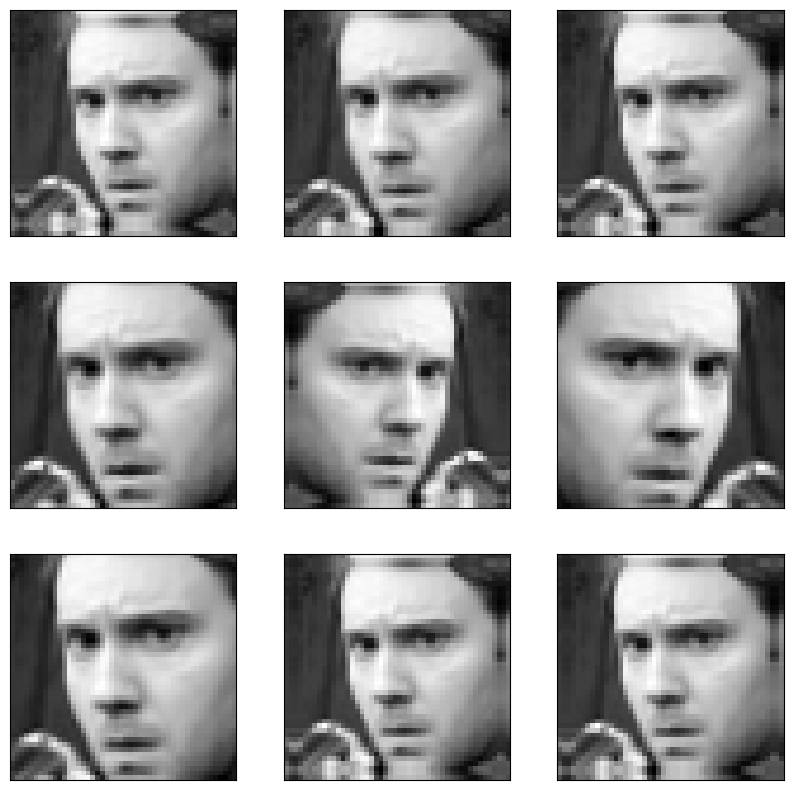

In [24]:
def augment_images(image):
    x = keras.layers.RandomFlip("horizontal")(image)
    x = keras.layers.RandomZoom(0.2)(x)
    return x

augmented_images = [augment_images(np.expand_dims(train_faces[0],axis=0)) for i in range(9)]
fig = plt.figure(figsize=(10, 10))
for i in range(9):
    ax = fig.add_subplot(3, 3, i+1, xticks=[], yticks=[])
    ax.imshow(tf.keras.preprocessing.image.array_to_img(augmented_images[i][0]), cmap='gray', vmin=0, vmax=255)

We take our model `wider_model` from Problem 2(c) and add a random flip and random zoom as **layers** before the rescaling layer.

In [32]:
input = keras.Input(shape=(48, 48, 3))

### DATA AUGMENTATION ###
h = keras.layers.RandomFlip("horizontal")(input)
h = keras.layers.RandomZoom(0.2)(h)

### YOUR CODE HERE ###
# Please insert your code from wider_model here.
h = keras.layers.Rescaling(1./255)(input)
h = keras.layers.Conv2D(kernel_size=2, filters=32, activation='relu', name="Conv_1")(h)
h = keras.layers.MaxPooling2D(pool_size=2)(h)

h = keras.layers.Conv2D(kernel_size=2, filters=32, activation='relu', name="Conv_2")(h)
h = keras.layers.MaxPooling2D(pool_size=2)(h)

h = keras.layers.Conv2D(kernel_size=2, filters=32, activation='relu', name="Conv_3")(h)
h = keras.layers.MaxPooling2D(pool_size=2)(h)

h = keras.layers.Flatten()(h)
h = keras.layers.Dense(256, activation='relu', name="Dense_1")(h)
output = keras.layers.Dense(7, activation='softmax', name="Output")(h)

model_augmented = keras.Model(input, output, name='augmented_CNN_model')
model_augmented.summary()

Model: "augmented_CNN_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 47, 47, 32)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 22, 22, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_3 (Conv2D)                 │ (None, 10, 10, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_1 (Dense)                 │ (None, 256)            │       205,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 215,527 (841.90 KB)

 Trainable params: 215,527 (841.90 KB)

 Non-trainable params: 0 (0.00 B)

Train the model (using the same parameters as all previous questions), show the accuracy vs. epoch curve, and report the accuracy on the test set.

In [33]:
model_augmented.compile(optimizer="adam", loss="categorical_crossentropy",
                        metrics=["accuracy"])

model_augmented_history = model_augmented.fit(train_faces, train_emotions,
                                              batch_size=64, epochs=30,
                                              validation_split=0.2)

Epoch 1/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.3201 - loss: 1.6942 - val_accuracy: 0.4028 - val_loss: 1.5635
Epoch 2/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4240 - loss: 1.5113 - val_accuracy: 0.4455 - val_loss: 1.4515
Epoch 3/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4653 - loss: 1.4038 - val_accuracy: 0.4716 - val_loss: 1.3834
Epoch 4/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4973 - loss: 1.3240 - val_accuracy: 0.4911 - val_loss: 1.3363
Epoch 5/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5233 - loss: 1.2554 - val_accuracy: 0.5113 - val_loss: 1.2992
Epoch 6/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5509 - loss: 1.1919 - val_accuracy: 0.5167 - val_loss: 1.2899
Epoch 7/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5776 - loss: 1.1281 - val_accuracy: 0.5216 - val_loss: 1.2894
Epoch 8/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6001 - loss: 1.0711 - val_accuracy: 0

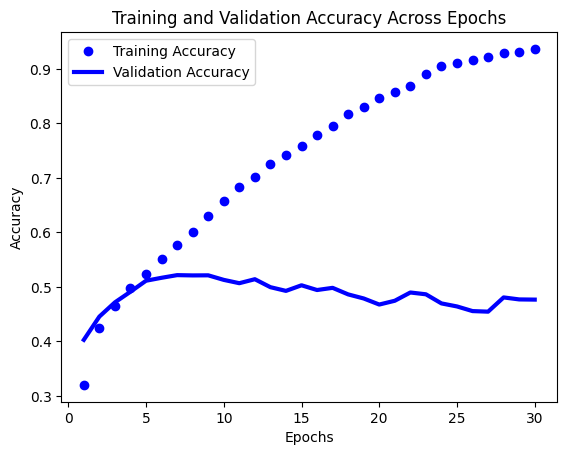

In [34]:
plot_accuracy(model_augmented_history)

In [35]:
# Calculate the test accuracy
### YOUR CODE HERE ###
deeper_model.evaluate(test_faces, test_emotions)

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4525 - loss: 3.6121


[3.612076759338379, 0.45249372720718384]

Compare this with `wider_model` and comment on the impact of data augmentation.

* No, it was a wash. We were able to get to val accuracy of 52.16 (compared to 52.77)
* No, the test accuracy decreased to 45.25% (compared to 49.83%)


# Problem 4: Transfer Learning and Fine-Tuning [25 points]

Next, we apply transfer learning to our problem using VGG19, a pre-trained model similar to ResNet50 from class. We will take VGG19 and make it "headless", then run it through our own "little" NN.

We will take three different approaches to this:

1. Part (a): **Base Transfer Learning**. Fix the weights from headless VGG19 and learn the weights on the little NN.
2. Part (b): **Some fine-tuning** Fix the weights on the top 6 out of 19 layers of VGG19, but allow the weights from the remaining 13 layers to be optimized by SGD/Adam, in addition to those of the little NN.
3. Part (c): **Fine-Tuning** Allow all weights in VGG19 to be tuned, in addition to the little NN.

For each of the models, we will plot their train/validation accuracy curve, compute their test accuracy, and compute a confusion matrix.

## Part (a): No Fine Tuning [5 Points]

Let us fetch the VGG19 model, making sure to set `include_top=False` so that we do not take its output layer. We also set `trainable=False` to indicate that the parameters in these 19 layers are not trainable.



In [36]:
base_model = keras.applications.VGG19(
    include_top=False,   # this makes VGG19 headless
    weights="imagenet",
    input_tensor=None,
    input_shape=(48, 48, 3),
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
)

# Freeze the base_model so that it is not trainable at all
base_model.trainable = False

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


We build a neural network that performs data augmentation and rescaling, then uses the VGG19, and finally has one dense layer before the output layer.

In [38]:
inputs = keras.Input(shape=(48,48,3))

x = keras.layers.RandomFlip("horizontal")(inputs)
x = keras.layers.RandomZoom(0.2)(x)
x = keras.layers.Rescaling(1./255)(x) # normalizing

# Add layers from base_model one at a time
x = base_model(x)

x = keras.layers.Flatten()(x)
x = keras.layers.Dense(256, activation='relu')(x)
outputs = keras.layers.Dense(7, activation='softmax')(x)

transfer_model = keras.Model(inputs, outputs, name='transfer_model')
transfer_model.summary()

Model: "transfer_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_13 (RandomFlip)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_13 (RandomZoom)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_6 (Rescaling)         │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 1, 1, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,157,511 (76.89 MB)

 Trainable params: 133,127 (520.03 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

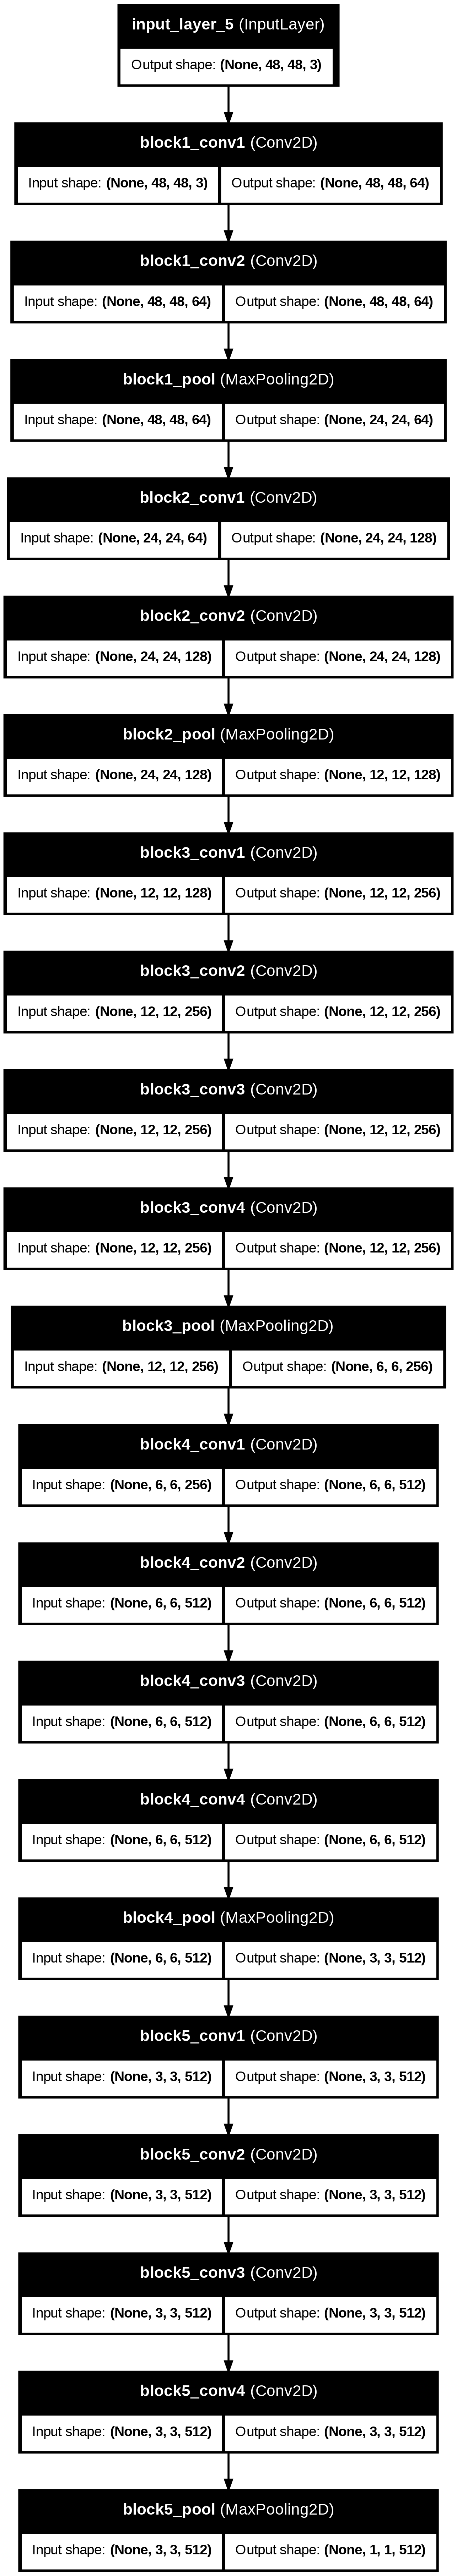

In [42]:
keras.utils.plot_model(base_model, show_shapes=True, show_layer_names=True)


Train the model. Here, we use a learning rate of 0.00002 to get better convergence.

In [43]:
transfer_model.compile(loss='categorical_crossentropy',
            optimizer=keras.optimizers.Adam(2e-5),
            metrics=['accuracy'])

transfer_model_history = transfer_model.fit(train_faces, train_emotions, epochs=30, validation_split=0.2)

Epoch 1/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.2448 - loss: 1.8299 - val_accuracy: 0.2860 - val_loss: 1.7456
Epoch 2/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.3020 - loss: 1.7311 - val_accuracy: 0.3236 - val_loss: 1.6926
Epoch 3/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.3224 - loss: 1.6991 - val_accuracy: 0.3375 - val_loss: 1.6672
Epoch 4/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.3301 - loss: 1.6835 - val_accuracy: 0.3433 - val_loss: 1.6523
Epoch 5/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.3364 - loss: 1.6677 - val_accuracy: 0.3483 - val_loss: 1.6420
Epoch 6/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.3377 - loss: 1.6622 - val_accuracy: 0.3525 - val_loss: 1.6336
Epoch 7/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.3415 - loss: 1.6540 - val_accuracy: 0.3558 - val_loss: 1.6263
Epoch 8/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.3451 - loss: 1.6489 - 

We can plot the training and validation accuracy curve.

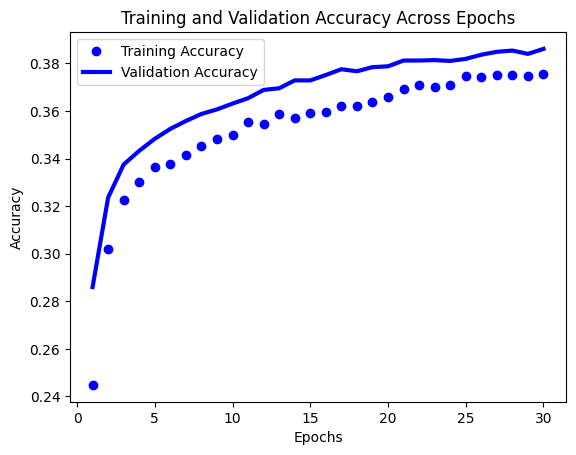

In [44]:
plot_accuracy(transfer_model_history)

Let's also calculate the confusion matrix and the accuracy on the test set.

The function `show_confusion_matrix` has been written for you below. You can apply it to any Keras Model and it will calculate:
* Test accuracy
* A confusion matrix. Recall that each row of the confusion matrix are the actual labels and each column are the predictions. For example, if element in row `happy` and column `sad` is 250, then there are 250 data points in the test set where the true label is `happy` but we predicted `sad`.
* A heatmap of the confusion matrix, where each row is normalized to add up to 1.0. For example, if element in row `happy` and column `sad` is 0.25, then that means 25% of data points with a true label of `happy` were predicted as `sad`.

225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step
*************************
* Test Accuracy: 0.3757 *
*************************


,angry,disgust,fear,happy,sad,surprise,neutral
angry,114,0,44,468,129,61,142
disgust,7,0,14,59,14,7,10
fear,46,0,135,403,142,146,152
happy,55,0,51,1344,110,49,165
sad,77,0,95,554,300,31,190
surprise,30,0,63,199,21,406,112
neutral,66,0,62,548,101,58,398


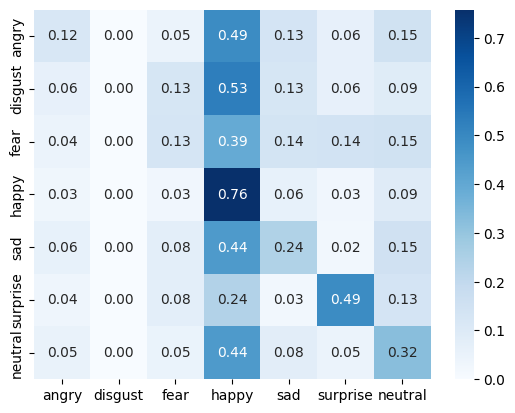

In [45]:
from IPython.display import display

def show_confusion_matrix(model):
    """
    Calculates the test accuracy, confusion matrix and heat map for a model.
    """
    global test_faces, test_emotions, emotions_names

    y_pred = model.predict(test_faces).argmax(axis=1)
    y_actual = test_emotions.argmax(axis=1)

    print('*************************\n* Test Accuracy: %.4f *\n*************************' % metrics.accuracy_score(y_actual, y_pred))

    cm = pd.DataFrame(metrics.confusion_matrix(y_actual, y_pred), index=emotions_names, columns=emotions_names)
    display(cm)

    cm = cm.div(cm.sum(axis=1), axis=0)

    sns.heatmap(cm, cmap="Blues", annot=True, fmt=".2f")

show_confusion_matrix(transfer_model)

Please comment briefly on the model's performance.

<font color='red'> **Your Answer** </font>

_Please replace this text with your answer_

## Part (b): Some Fine Tuning [5 Points]
In this part, we will allow our optimization model to tune **some** of the layers from VGG19. In particular, we will only freeze the first 15 layers and allow the remaining layers to be trained.


In [48]:
base_model = keras.applications.VGG19(
    include_top=False,   # this makes VGG19 headless
    weights="imagenet",
    input_tensor=None,
    input_shape=(48, 48, 3), # Set input_shape to properly access internal layers
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
)

# Freeze the first 15 layers of the VGG19 base_model
# This makes only the later VGG19 layers and custom dense layers trainable.
for layer in base_model.layers[:15]:
    layer.trainable = False

inputs = keras.Input(shape=(48,48,3))

x = keras.layers.RandomFlip("horizontal")(inputs)
x = keras.layers.RandomZoom(0.2)(x)
x = keras.layers.Rescaling(1./255)(x) # normalizing

# Add the partially-frozen base_model
x = base_model(x)

x = keras.layers.Flatten()(x)
x = keras.layers.Dense(256, activation='relu')(x)
outputs = keras.layers.Dense(7, activation='softmax')(x)

partial_model = keras.Model(inputs, outputs, name='partial_fine_tune_model')

# No need to iterate through partial_model.layers[:15] here anymore
# as the freezing was applied to the internal layers of base_model directly.

partial_model.summary()

Model: "partial_fine_tune_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_16 (RandomFlip)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_16 (RandomZoom)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_9 (Rescaling)         │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 1, 1, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,157,511 (76.89 MB)

 Trainable params: 11,932,167 (45.52 MB)

 Non-trainable params: 8,225,344 (31.38 MB)

Let's see which layers are trainable. Notice that VGG19 consists of 4 blocks of convolution filters (block1_conv1, block1_conv2, ..., block5_conv4). We are allowing block4 and block5 to be trained and freezing blocks 1, 2 and 3.

In [49]:
for i, layer in enumerate(partial_model.layers):
    print('Layer %d: %s (%s), Trainable=%s' % (i+1, layer.name, layer.__class__.__name__, layer.trainable))

Layer 1: input_layer_13 (InputLayer), Trainable=True
Layer 2: random_flip_16 (RandomFlip), Trainable=True
Layer 3: random_zoom_16 (RandomZoom), Trainable=True
Layer 4: rescaling_9 (Rescaling), Trainable=True
Layer 5: vgg19 (Functional), Trainable=True
Layer 6: flatten_7 (Flatten), Trainable=True
Layer 7: dense_4 (Dense), Trainable=True
Layer 8: dense_5 (Dense), Trainable=True


Train the model and examine its train/validation curve, test accuracy and confusion matrix.

In [50]:
partial_model.compile(loss='categorical_crossentropy',
            optimizer=keras.optimizers.Adam(2e-5),
            metrics=['accuracy'])

partial_model_history = partial_model.fit(train_faces, train_emotions, epochs=30, validation_split=0.2)

Epoch 1/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - accuracy: 0.3917 - loss: 1.5531 - val_accuracy: 0.4727 - val_loss: 1.3872
Epoch 2/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.4699 - loss: 1.3744 - val_accuracy: 0.4967 - val_loss: 1.3172
Epoch 3/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 28s 38ms/step - accuracy: 0.5077 - loss: 1.2892 - val_accuracy: 0.5122 - val_loss: 1.2818
Epoch 4/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.5369 - loss: 1.2242 - val_accuracy: 0.5235 - val_loss: 1.2397
Epoch 5/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.5553 - loss: 1.1724 - val_accuracy: 0.5404 - val_loss: 1.2159
Epoch 6/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.5846 - loss: 1.1132 - val_accuracy: 0.5456 - val_loss: 1.2188
Epoch 7/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.5997 - loss: 1.0637 - val_accuracy: 0.5512 - val_loss: 1.1916
Epoch 8/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.6242 - loss: 1.0089 - 

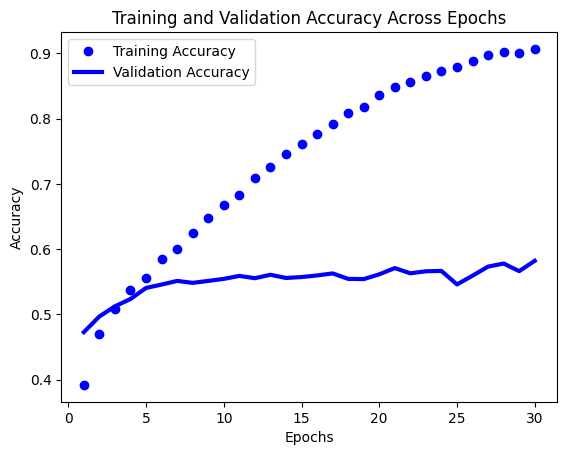

In [51]:
plot_accuracy(partial_model_history)

225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step
*************************
* Test Accuracy: 0.5829 *
*************************


,angry,disgust,fear,happy,sad,surprise,neutral
angry,468,1,76,116,132,25,140
disgust,23,53,10,9,11,1,4
fear,128,1,391,77,202,68,157
happy,65,1,25,1435,85,22,141
sad,168,2,103,175,559,19,221
surprise,34,1,68,64,30,594,40
neutral,86,1,62,192,179,29,684


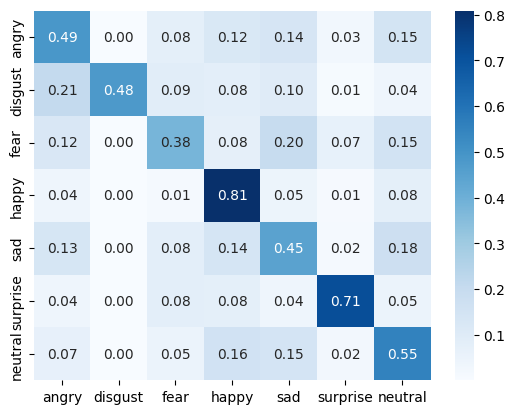

In [52]:
show_confusion_matrix(partial_model)

Please comment briefly on the model's performance.  

<font color='red'> **Your Answer** </font>

_Please replace this text with your answer_

## Part (c): Fine Tuning [5 Points]
Now, let's try a transfer learning model where all layers can be fine tuned.

In [54]:
base_model = keras.applications.VGG19(
    include_top=False,   # this makes VGG19 headless
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
)

inputs = keras.Input(shape=(48,48,3))

x = keras.layers.RandomFlip("horizontal")(inputs)
x = keras.layers.RandomZoom(0.2)(x)
x = keras.layers.Rescaling(1./255)(x) # normalizing

# Add layers from base_model
x = base_model(x)

x = keras.layers.Flatten()(x)
x = keras.layers.Dense(256, activation='relu')(x)
outputs = keras.layers.Dense(7, activation='softmax')(x)

tuned_model = keras.Model(inputs, outputs, name='full_fine_tune_model')

# Let's see which layers are trainable
for i, layer in enumerate(tuned_model.layers):
    print('Layer %d: %s (%s), Trainable=%s' % (i+1, layer.name, layer.__class__.__name__, layer.trainable))

tuned_model.summary()

Layer 1: input_layer_17 (InputLayer), Trainable=True
Layer 2: random_flip_18 (RandomFlip), Trainable=True
Layer 3: random_zoom_18 (RandomZoom), Trainable=True
Layer 4: rescaling_11 (Rescaling), Trainable=True
Layer 5: vgg19 (Functional), Trainable=True
Layer 6: flatten_9 (Flatten), Trainable=True
Layer 7: dense_8 (Dense), Trainable=True
Layer 8: dense_9 (Dense), Trainable=True


Model: "full_fine_tune_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_17 (InputLayer)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_18 (RandomFlip)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_18 (RandomZoom)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_11 (Rescaling)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 1, 1, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,157,511 (76.89 MB)

 Trainable params: 20,157,511 (76.89 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:
tuned_model.compile(loss='categorical_crossentropy',
            optimizer=keras.optimizers.Adam(2e-5),
            metrics=['accuracy'])

tuned_model_history = tuned_model.fit(train_faces, train_emotions, epochs=30, validation_split=0.2)

Epoch 1/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 54s 67ms/step - accuracy: 0.4320 - loss: 1.4566 - val_accuracy: 0.5019 - val_loss: 1.3429
Epoch 2/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 47s 66ms/step - accuracy: 0.5348 - loss: 1.2171 - val_accuracy: 0.5505 - val_loss: 1.1929
Epoch 3/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 47s 66ms/step - accuracy: 0.5706 - loss: 1.1209 - val_accuracy: 0.5742 - val_loss: 1.1229
Epoch 4/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 47s 65ms/step - accuracy: 0.5999 - loss: 1.0531 - val_accuracy: 0.5925 - val_loss: 1.0886
Epoch 5/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 47s 65ms/step - accuracy: 0.6273 - loss: 0.9912 - val_accuracy: 0.6041 - val_loss: 1.0460
Epoch 6/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 47s 65ms/step - accuracy: 0.6509 - loss: 0.9293 - val_accuracy: 0.6097 - val_loss: 1.0477
Epoch 7/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 47s 66ms/step - accuracy: 0.6748 - loss: 0.8792 - val_accuracy: 0.5986 - val_loss: 1.1060
Epoch 8/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 47s 65ms/step - accuracy: 0.6960 - loss: 0.8253 - 

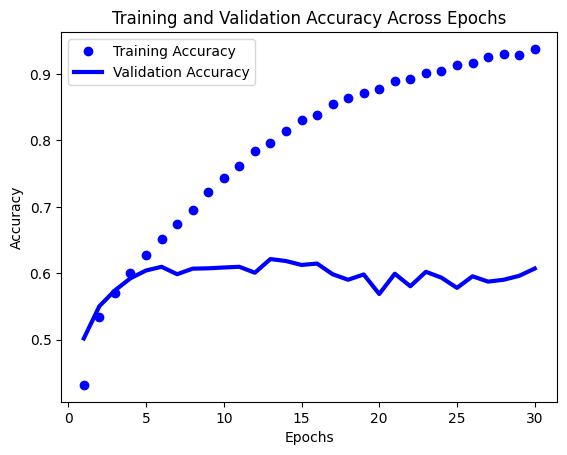

In [56]:
plot_accuracy(tuned_model_history)

225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step
*************************
* Test Accuracy: 0.6069 *
*************************


,angry,disgust,fear,happy,sad,surprise,neutral
angry,483,5,106,77,130,24,133
disgust,40,45,9,5,5,3,4
fear,112,3,462,51,205,74,117
happy,32,0,38,1512,76,26,90
sad,140,4,149,78,596,35,245
surprise,30,0,99,49,27,588,38
neutral,75,1,109,134,214,30,670


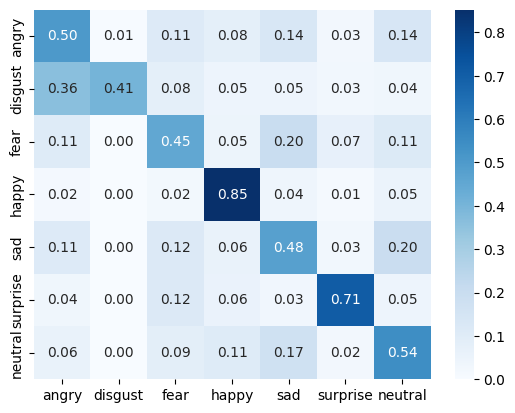

In [57]:
show_confusion_matrix(tuned_model)

Please comment briefly on the model's performance.  

<font color='red'> **Your Answer** </font>

_Please replace this text with your answer_

## Part (d): Comparison [10 Points]

Please fill in the table below with the test accuracies of the three models above, as well as that of `wider_model` from Problem 2.


Model Test Accuracy:
* Model (a) with no fine tuning: 37.57%
* Model (b) with some fine tuning: 58.29%
* Model (c) with fine tuning: 60.69%
* `wider_model` from Problem 2(a)-(c): 49.83%


Comment on the performance of Models (a), (b) and (c). In particular, please address the following questions:

* Why do models (b) and (c) perform so much better than `wider_model`?
Trained on a much bigger data set. The issue we were having was with over fitting. I think learning from larger data set transfers and helps to create improve accuracy.

* Why do you think Model (a) performs so poorly?

It is trained for a different purpose - cat vs dog vs human and we are here interested in labeling emotions.

* Why do you think Model (c) performs better than model (b)?

Seems like even early layers (first order features can benefit) from some fine tuning as the problem is quite different.

